# Hillstrom Email Marketing: дизайн и анализ A/B-теста

## 1. Цель и суть эксперимента

Hillstrom — рандомизированный маркетинговый эксперимент с тремя группами:

- **No E-Mail** — контроль без письма;
- **Mens E-Mail** — письмо с мужской подборкой;
- **Womens E-Mail** — письмо с женской подборкой.

Цель анализа — оценить, увеличивают ли e-mail кампании траты клиентов относительно контроля. Ноутбук последовательно проверяет качество данных и рандомизации, оценивает чувствительность дизайна, а затем измеряет эффект по основной и вторичным метрикам.

### Подготовка данных

**Зачем:** зафиксировать воспроизводимое окружение и загрузить единственный исходный датасет проекта. **Что делаем:** находим корень проекта, читаем CSV и задаём порядок групп и параметры теста. **Как читать результат:** ожидаем 64 000 строк и 12 колонок; первые строки нужны только для проверки структуры, а не для выводов об эффекте.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.proportion import proportions_ztest

root_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    root for root in root_candidates
    if (root / "data" / "raw" / "hillstrom.csv").exists()
)
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "hillstrom.csv"

GROUP_ORDER = ["No E-Mail", "Mens E-Mail", "Womens E-Mail"]
GROUP_LABELS = ["Control", "Men's", "Women's"]
ALPHA = 0.05
POWER = 0.80

df = pd.read_csv(DATA_PATH)

print(f"Размер данных: {df.shape[0]:,} строк × {df.shape[1]} колонок")
display(df.head())

Размер данных: 64,000 строк × 12 колонок


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 2. Роли колонок

Для корректного причинного анализа важно не смешивать признаки, измеренные до воздействия, назначение группы и результаты после воздействия.

| Роль | Колонки | Использование |
|---|---|---|
| **Pre-treatment** | `recency`, `history_segment`, `history`, `mens`, `womens`, `zip_code`, `newbie`, `channel` | Проверка баланса рандомизации; потенциальные ковариаты |
| **Treatment** | `segment` | Назначенная экспериментальная группа |
| **Post-treatment** | `visit`, `conversion`, `spend` | Результаты, на которые могло повлиять письмо |

Post-treatment метрики нельзя использовать как ковариаты для корректировки основного эффекта: они уже могли измениться из-за treatment.

## 3. Дизайн анализа

- **Primary metric:** `spend` — средние траты на пользователя (Spend per User).
- **Secondary metrics:** `conversion` и `visit` — доли пользователей с покупкой и визитом.
- **Health / guardrail:** в датасете нет отписок, жалоб, churn или иных негативных сигналов. Поэтому анализ показывает эффективность, но не может полноценно проверить безопасность коммуникации для клиентской базы.
- **Статистические параметры:** $\alpha=0{,}05$, power $=0{,}80$, двусторонняя альтернатива.
- **Семейство сравнений:** `Mens E-Mail` vs control и `Womens E-Mail` vs control. Для итоговых p-value применяем пошаговую поправку Holm внутри каждой метрики.
- **Длительность:** согласно описанию Hillstrom, post-treatment поведение наблюдалось **14 дней**. В данных нет дневного трафика и временных меток, поэтому восстановить traffic-based duration или проверить эффект по дням нельзя.

Это ретроспективный анализ готового эксперимента: параметры выше задают правила интерпретации, а не доказывают, что исходный тест был заранее спланирован именно так.

## 4. Качество данных

**Зачем:** ошибки формата, пропуски и нелогичные значения могут исказить все последующие тесты. **Что считаем:** пропуски, типы и уникальность колонок, допустимость бинарных полей, отрицательные траты и логическую связь `conversion → visit`. **Как читать результат:** нули в проверках ошибок означают, что явных нарушений нет; одинаковые строки трактуем отдельно.

In [2]:
binary_columns = ["mens", "womens", "newbie", "visit", "conversion"]
expected_segments = set(GROUP_ORDER)

column_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
})

quality_checks = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "missing_values": int(df.isna().sum().sum()),
    "exactly_equal_rows": int(df.duplicated().sum()),
    "invalid_binary_values": int(sum(~df[col].isin([0, 1]) for col in binary_columns).sum()),
    "negative_spend": int((df["spend"] < 0).sum()),
    "conversion_without_visit": int((df["conversion"] > df["visit"]).sum()),
    "unexpected_segments": len(set(df["segment"]) - expected_segments),
}).to_frame("value")

display(column_profile)
display(quality_checks)

,dtype,missing,unique
recency,int64,0,12
history_segment,str,0,7
history,float64,0,34833
mens,int64,0,2
womens,int64,0,2
zip_code,str,0,3
newbie,int64,0,2
channel,str,0,3
segment,str,0,3
visit,int64,0,2


,value
rows,64000
columns,12
missing_values,0
exactly_equal_rows,6562
invalid_binary_values,0
negative_spend,0
conversion_without_visit,0
unexpected_segments,0


Пропусков, отрицательных трат, неверных бинарных значений и конверсий без визита нет. Найдено 6 562 полностью одинаковых строк, однако в данных отсутствует `customer_id`, а набор признаков дискретный и у большинства клиентов нулевые outcome. Поэтому такие строки могут принадлежать разным клиентам; удалять их без идентификатора было бы необоснованно. В анализе сохраняем все 64 000 наблюдений.

## 5. Sample Ratio Mismatch (SRM)

**Зачем:** сначала проверяем, не нарушилось ли ожидаемое распределение 1/3–1/3–1/3. **Что считаем:** размеры, доли групп и chi-square goodness-of-fit test. **Как читать результат:** маленький p-value указывал бы на несоответствие плану; при $p>0{,}05$ оснований говорить об SRM нет.

In [3]:
group_counts = df["segment"].value_counts().reindex(GROUP_ORDER)
group_shares_pct = group_counts / len(df) * 100
expected_counts = np.repeat(len(df) / len(GROUP_ORDER), len(GROUP_ORDER))
chi2_stat, srm_p_value = stats.chisquare(group_counts.to_numpy(), expected_counts)

srm_table = pd.DataFrame({
    "users": group_counts,
    "share_pct": group_shares_pct,
    "expected_users": expected_counts,
})

display(srm_table.round({"share_pct": 4, "expected_users": 2}))
print(f"Chi-square = {chi2_stat:.4f}")
print(f"p-value = {srm_p_value:.4f}")

,users,share_pct,expected_users
segment,,,
No E-Mail,21306,33.2906,21333.33
Mens E-Mail,21307,33.2922,21333.33
Womens E-Mail,21387,33.4172,21333.33


Chi-square = 0.2025
p-value = 0.9037


Фактические доли — 33,29% / 33,29% / 33,42% в порядке Control / Men's / Women's. Получено $\chi^2\approx0{,}2025$ и $p\approx0{,}9037$: распределение согласуется с планом 1/3–1/3–1/3, признаков SRM нет.

**Зачем график:** визуально проверить масштаб отклонений от равных долей. **Что показываем:** фактическую долю каждой группы и ожидаемую линию 33,33%. **Как читать:** близость столбцов к пунктирной линии подтверждает результат chi-square теста.

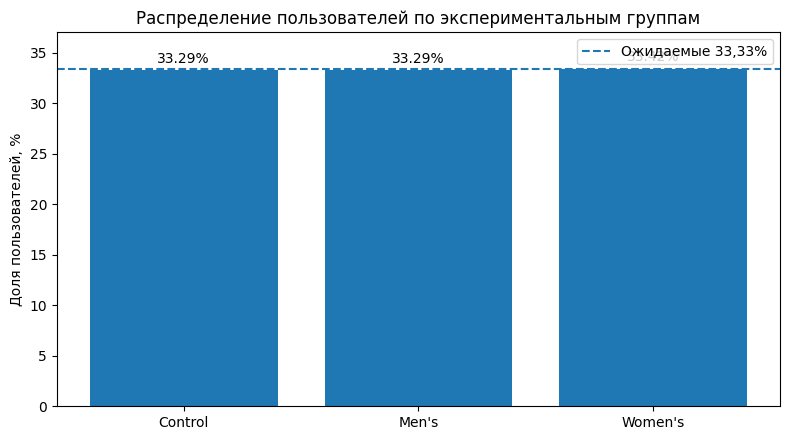

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(GROUP_LABELS, group_shares_pct.to_numpy())
ax.axhline(100 / 3, linestyle="--", linewidth=1.5, label="Ожидаемые 33,33%")
ax.bar_label(bars, labels=[f"{value:.2f}%" for value in group_shares_pct], padding=3)
ax.set_title("Распределение пользователей по экспериментальным группам")
ax.set_ylabel("Доля пользователей, %")
ax.set_ylim(0, 37)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Баланс pre-treatment признаков

### Числовые признаки: `history` и `recency`

**Зачем:** SRM проверяет только размеры групп, но не их сходство по исходным характеристикам. **Что считаем:** описательные статистики и standardized mean difference (SMD) каждой treatment-группы относительно контроля. **Как читать:** $|SMD|<0{,}1$ обычно считают хорошим балансом; здесь интересен порядок величины, а не p-value на большой выборке.

Для числового признака используем формулу:

$$
SMD = \frac{\bar{x}_{T} - \bar{x}_{C}}
{\sqrt{\frac{s_T^2+s_C^2}{2}}},
$$

где $\bar{x}_{T}$ и $\bar{x}_{C}$ — средние в treatment и control, а $s_T$ и $s_C$ — их стандартные отклонения. То есть SMD показывает разницу средних в единицах объединённого стандартного отклонения.

In [5]:
numeric_balance = (
    df.groupby("segment")[["history", "recency"]]
      .agg(["mean", "std", "median"])
      .reindex(GROUP_ORDER)
)

def standardized_mean_difference(data, feature, treatment, control="No E-Mail"):
    treatment_values = data.loc[data["segment"] == treatment, feature]
    control_values = data.loc[data["segment"] == control, feature]
    pooled_std = np.sqrt(
        (treatment_values.var(ddof=1) + control_values.var(ddof=1)) / 2
    )
    return (treatment_values.mean() - control_values.mean()) / pooled_std

smd_rows = []
for treatment in ["Mens E-Mail", "Womens E-Mail"]:
    for feature in ["history", "recency"]:
        smd_rows.append({
            "comparison": f"{treatment} vs No E-Mail",
            "feature": feature,
            "SMD": standardized_mean_difference(df, feature, treatment),
        })
smd_table = pd.DataFrame(smd_rows)

display(numeric_balance.round(4))
display(smd_table.round(4))

history                    recency               
                   mean       std   median    mean     std median
segment                                                          
No E-Mail      240.8827  252.7394  156.655  5.7497  3.4975    5.0
Mens E-Mail    242.8359  260.3557  157.220  5.7736  3.5133    6.0
Womens E-Mail  242.5366  255.3329  160.090  5.7678  3.5120    6.0

,comparison,feature,SMD
0,Mens E-Mail vs No E-Mail,history,0.0076
1,Mens E-Mail vs No E-Mail,recency,0.0068
2,Womens E-Mail vs No E-Mail,history,0.0065
3,Womens E-Mail vs No E-Mail,recency,0.0052


Все SMD близки к нулю: Men's vs Control — 0,0076 (`history`) и 0,0068 (`recency`); Women's vs Control — 0,0065 и 0,0052. Это значительно ниже ориентира 0,1 и поддерживает корректность рандомизации.

**Пример интерпретации:** SMD = 0,0076 для `history` в сравнении Men's vs Control означает, что среднее значение `history` в Men's-группе выше контрольного всего на **0,0076 объединённого стандартного отклонения**. Знак «+» показывает направление различия, а модуль — его размер. Поскольку 0,0076 намного меньше практического ориентира 0,1, такой дисбаланс пренебрежимо мал. SMD безразмерен, поэтому его удобно сравнивать между признаками с разными шкалами.

### Бинарные признаки

**Зачем:** сравнить доли исходных бинарных характеристик в группах. **Что считаем:** нормированные по строкам таблицы сопряжённости для `mens`, `womens`, `newbie`. **Как читать:** значения в каждой строке суммируются до 1; близкие доли между группами означают баланс.

In [6]:
for feature in ["mens", "womens", "newbie"]:
    table = (
        pd.crosstab(df["segment"], df[feature], normalize="index")
          .reindex(GROUP_ORDER)
    )
    print(f"Доли для {feature}")
    display(table.round(4))

Доли для mens


mens,0,1
segment,,
No E-Mail,0.4468,0.5532
Mens E-Mail,0.4491,0.5509
Womens E-Mail,0.4511,0.5489


Доли для womens


womens,0,1
segment,,
No E-Mail,0.4524,0.5476
Mens E-Mail,0.4486,0.5514
Womens E-Mail,0.4499,0.5501


Доли для newbie


newbie,0,1
segment,,
No E-Mail,0.4980,0.5020
Mens E-Mail,0.4985,0.5015
Womens E-Mail,0.4968,0.5032


### Категориальные признаки

**Зачем:** убедиться, что география и исходный канал контакта не перекошены между группами. **Что считаем:** нормированные crosstab для `zip_code` и `channel`. **Как читать:** сравниваем столбцы внутри признака; различия здесь малы и не указывают на заметный дисбаланс.

In [7]:
for feature in ["zip_code", "channel"]:
    table = (
        pd.crosstab(df["segment"], df[feature], normalize="index")
          .reindex(GROUP_ORDER)
    )
    print(f"Доли для {feature}")
    display(table.round(4))

Доли для zip_code


zip_code,Rural,Surburban,Urban
segment,,,
No E-Mail,0.1473,0.4518,0.4009
Mens E-Mail,0.1522,0.4459,0.4019
Womens E-Mail,0.1487,0.4512,0.4001


Доли для channel


channel,Multichannel,Phone,Web
segment,,,
No E-Mail,0.1223,0.4378,0.4399
Mens E-Mail,0.1209,0.4337,0.4454
Womens E-Mail,0.1206,0.4420,0.4374


Числовые, бинарные и категориальные pre-treatment признаки практически одинаково распределены между группами. Вместе с отсутствием SRM это не доказывает идеальную рандомизацию, но не показывает видимых нарушений.

## 7. Ретроспективный MDE / sensitivity analysis для `spend`

**Зачем:** оценить, эффекты какого масштаба был способен обнаружить уже проведённый эксперимент при фактических размерах групп. **Что считаем:** минимальный обнаружимый эффект в денежных единицах при power 0,80 — отдельно с $\alpha=0{,}05$ и с консервативным $\alpha=0{,}025$ для двух сравнений. **Как читать:** меньший MDE означает большую чувствительность.

Важно: это **не pre-test planning**, потому что расчёт использует фактическую post-treatment дисперсию `spend`. Он описывает чувствительность готовой выборки, а не заранее обосновывает её размер.

In [8]:
spend_group_stats = (
    df.groupby("segment")["spend"]
      .agg(["count", "mean", "std"])
      .reindex(GROUP_ORDER)
)
power_analysis = TTestIndPower()

def retrospective_mde(treatment, alpha):
    control_stats = spend_group_stats.loc["No E-Mail"]
    treatment_stats = spend_group_stats.loc[treatment]
    ratio = treatment_stats["count"] / control_stats["count"]
    detectable_d = power_analysis.solve_power(
        effect_size=None,
        nobs1=control_stats["count"],
        alpha=alpha,
        power=POWER,
        ratio=ratio,
        alternative="two-sided",
    )
    pooled_std = np.sqrt(
        (control_stats["std"] ** 2 + treatment_stats["std"] ** 2) / 2
    )
    return detectable_d, detectable_d * pooled_std

mde_rows = []
for alpha_label, alpha_value in [("Без multiplicity", 0.05), ("Консервативно", 0.025)]:
    for treatment in ["Mens E-Mail", "Womens E-Mail"]:
        detectable_d, mde = retrospective_mde(treatment, alpha_value)
        mde_rows.append({
            "scenario": alpha_label,
            "comparison": f"{treatment} vs No E-Mail",
            "alpha": alpha_value,
            "detectable_Cohen_d": detectable_d,
            "MDE_spend": mde,
        })

display(spend_group_stats.round(4))
display(pd.DataFrame(mde_rows).round(4))

,count,mean,std
segment,,,
No E-Mail,21306,0.6528,11.5882
Mens E-Mail,21307,1.4226,17.7542
Womens E-Mail,21387,1.0772,15.1161


,scenario,comparison,alpha,detectable_Cohen_d,MDE_spend
0,Без multiplicity,Mens E-Mail vs No E-Mail,0.050,0.0271,0.4069
1,Без multiplicity,Womens E-Mail vs No E-Mail,0.050,0.0271,0.3652
2,Консервативно,Mens E-Mail vs No E-Mail,0.025,0.0299,0.4478
3,Консервативно,Womens E-Mail vs No E-Mail,0.025,0.0298,0.4019


Без поправки MDE составляет примерно 0,4069 для Men's и 0,3652 для Women's; при консервативном $\alpha=0{,}025$ — 0,4478 и 0,4019. **MDE не является порогом статистической значимости:** эффект меньше MDE всё ещё может оказаться значимым, а эффект больше MDE не обязан быть значимым в конкретной реализации данных. Это характеристика мощности при заданных допущениях.

## 8. Primary metric: Spend per User

**Зачем:** оценить бизнес-эффект каждой рассылки на основную метрику. **Что считаем:** средний `spend` по группам, абсолютный и относительный uplift каждой treatment-группы против контроля. **Как читать:** положительный uplift означает рост наблюдаемых средних трат относительно `No E-Mail`.

In [9]:
metric_summary = (
    df.groupby("segment")
      .agg(
          users=("segment", "size"),
          spend_per_user=("spend", "mean"),
          conversion_rate=("conversion", "mean"),
          visit_rate=("visit", "mean"),
      )
      .reindex(GROUP_ORDER)
)

control_spend_mean = metric_summary.loc["No E-Mail", "spend_per_user"]
spend_effect_rows = []
for treatment in ["Mens E-Mail", "Womens E-Mail"]:
    treatment_mean = metric_summary.loc[treatment, "spend_per_user"]
    absolute_uplift = treatment_mean - control_spend_mean
    spend_effect_rows.append({
        "comparison": f"{treatment} vs No E-Mail",
        "control_mean": control_spend_mean,
        "treatment_mean": treatment_mean,
        "absolute_uplift": absolute_uplift,
        "relative_uplift_pct": absolute_uplift / control_spend_mean * 100,
    })
spend_effects = pd.DataFrame(spend_effect_rows)

display(metric_summary.round(6))
display(spend_effects.round(4))

,users,spend_per_user,conversion_rate,visit_rate
segment,,,,
No E-Mail,21306,0.652789,0.005726,0.106167
Mens E-Mail,21307,1.422617,0.012531,0.182757
Womens E-Mail,21387,1.077202,0.008837,0.151400


,comparison,control_mean,treatment_mean,absolute_uplift,relative_uplift_pct
0,Mens E-Mail vs No E-Mail,0.6528,1.4226,0.7698,117.9289
1,Womens E-Mail vs No E-Mail,0.6528,1.0772,0.4244,65.0152


Средний Spend per User равен 0,6528 в контроле, 1,4226 в Men's и 1,0772 в Women's. Наблюдаемый uplift — +0,7698 (+117,93%) и +0,4244 (+65,02%).

**Зачем график:** сделать масштаб различий в primary metric наглядным. **Что показываем:** средний `spend` на пользователя в каждой группе. **Как читать:** высота столбца — наблюдаемое среднее, а не доверительный интервал и не самостоятельное доказательство значимости.

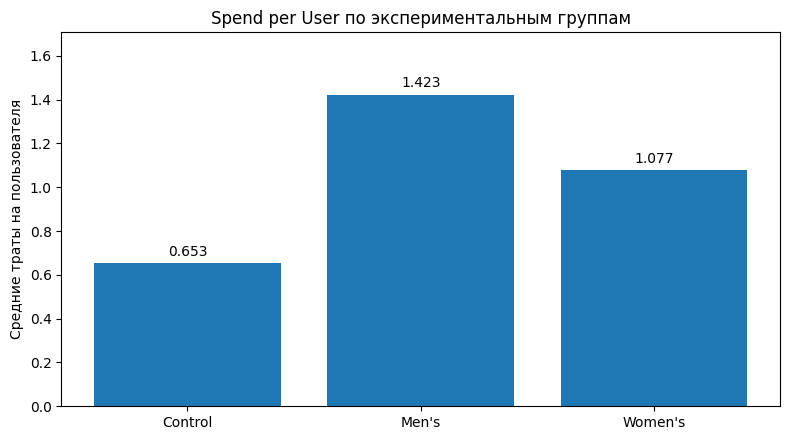

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
spend_means = metric_summary["spend_per_user"]
bars = ax.bar(GROUP_LABELS, spend_means.to_numpy())
ax.bar_label(bars, labels=[f"{value:.3f}" for value in spend_means], padding=3)
ax.set_title("Spend per User по экспериментальным группам")
ax.set_ylabel("Средние траты на пользователя")
ax.set_ylim(0, spend_means.max() * 1.2)
plt.tight_layout()
plt.show()

### Форма распределения `spend`

**Зачем:** средние траты могут быть нестабильны при большом числе нулей и редких крупных покупках. **Что считаем:** долю нулевых значений и основные описательные статистики. **Как читать:** чем выше zero share и разрыв между медианой и средним, тем сильнее zero inflation и асимметрия; поэтому дополняем Welch t-test непараметрическим bootstrap интервалом для разницы средних.

In [11]:
zero_spend_share = (df["spend"] == 0).mean()
spend_distribution = (
    df.groupby("segment")["spend"]
      .describe()[["count", "mean", "std", "50%", "max"]]
      .reindex(GROUP_ORDER)
)

print(f"Доля нулевых значений spend: {zero_spend_share:.6%}")
display(spend_distribution.round(4))

Доля нулевых значений spend: 99.096875%


,count,mean,std,50%,max
segment,,,,,
No E-Mail,21306.0,0.6528,11.5882,0.0,499.0
Mens E-Mail,21307.0,1.4226,17.7542,0.0,499.0
Womens E-Mail,21387.0,1.0772,15.1161,0.0,499.0


Около 99,096875% значений `spend` равны нулю, а медиана во всех группах равна 0. **Что считаем дальше:** percentile bootstrap 95% CI для разницы средних, 5 000 повторов и фиксированный seed. **Как читать:** если весь интервал выше нуля, данные поддерживают положительный uplift; интервалы индивидуальные, не simultaneous.

In [12]:
rng = np.random.default_rng(42)
control_spend = df.loc[df["segment"] == "No E-Mail", "spend"].to_numpy()

def bootstrap_mean_difference(treatment, n_boot=5_000):
    treatment_spend = df.loc[df["segment"] == treatment, "spend"].to_numpy()
    bootstrap_differences = []
    for _ in range(n_boot):
        control_sample = rng.choice(control_spend, size=len(control_spend), replace=True)
        treatment_sample = rng.choice(
            treatment_spend, size=len(treatment_spend), replace=True
        )
        bootstrap_differences.append(treatment_sample.mean() - control_sample.mean())
    bootstrap_differences = np.asarray(bootstrap_differences)
    return {
        "comparison": f"{treatment} vs No E-Mail",
        "observed_uplift": treatment_spend.mean() - control_spend.mean(),
        "ci_2.5%": np.percentile(bootstrap_differences, 2.5),
        "ci_97.5%": np.percentile(bootstrap_differences, 97.5),
    }

bootstrap_spend = pd.DataFrame([
    bootstrap_mean_difference("Mens E-Mail"),
    bootstrap_mean_difference("Womens E-Mail"),
])
display(bootstrap_spend.round(4))

,comparison,observed_uplift,ci_2.5%,ci_97.5%
0,Mens E-Mail vs No E-Mail,0.7698,0.4937,1.0610
1,Womens E-Mail vs No E-Mail,0.4244,0.1683,0.6854


Bootstrap 95% CI: Men's [0,4937; 1,0610], Women's [0,1683; 0,6854]. Оба интервала выше нуля.

**Зачем формальный тест:** проверить нулевую гипотезу о равенстве средних, не предполагая равенство дисперсий. **Что считаем:** двусторонние Welch t-tests и Holm-adjusted p-values для двух сравнений с контролем. **Как читать:** решение принимаем по `holm_p_value < 0.05`, а не по размеру uplift или MDE.

In [13]:
spend_test_rows = []
for treatment in ["Mens E-Mail", "Womens E-Mail"]:
    treatment_spend = df.loc[df["segment"] == treatment, "spend"]
    test = stats.ttest_ind(treatment_spend, control_spend, equal_var=False)
    spend_test_rows.append({
        "comparison": f"{treatment} vs No E-Mail",
        "welch_t": test.statistic,
        "raw_p_value": test.pvalue,
    })

spend_tests = pd.DataFrame(spend_test_rows)
spend_reject, spend_holm_p, _, _ = multipletests(
    spend_tests["raw_p_value"], alpha=ALPHA, method="holm"
)
spend_tests["holm_p_value"] = spend_holm_p
spend_tests["reject_H0"] = spend_reject
display(spend_tests)

,comparison,welch_t,raw_p_value,holm_p_value,reject_H0
0,Mens E-Mail vs No E-Mail,5.300140,1.163815e-07,2.327630e-07,True
1,Womens E-Mail vs No E-Mail,3.256372,1.129397e-03,1.129397e-03,True


Raw p-values равны примерно $1{,}1638\cdot10^{-7}$ и 0,0011294; после Holm — $2{,}3276\cdot10^{-7}$ и 0,0011294. Для обеих кампаний отвергаем $H_0$: рост `spend` относительно контроля статистически значим в рамках выбранного семейства сравнений.

## 9. Secondary metric: conversion

**Зачем:** проверить, сопровождается ли рост трат увеличением доли покупателей. **Что считаем:** разницу долей, обычный 95% Wald CI, двусторонний z-test и Holm correction для двух сравнений с контролем. **Как читать:** положительный CI, не включающий 0, и adjusted p-value ниже 0,05 поддерживают рост conversion.

In [14]:
def proportion_comparisons(data, metric):
    rows = []
    control = data.loc[data["segment"] == "No E-Mail", metric]
    for treatment in ["Mens E-Mail", "Womens E-Mail"]:
        treatment_values = data.loc[data["segment"] == treatment, metric]
        control_rate = control.mean()
        treatment_rate = treatment_values.mean()
        uplift = treatment_rate - control_rate
        standard_error = np.sqrt(
            treatment_rate * (1 - treatment_rate) / len(treatment_values)
            + control_rate * (1 - control_rate) / len(control)
        )
        z_stat, p_value = proportions_ztest(
            [treatment_values.sum(), control.sum()],
            [len(treatment_values), len(control)],
            alternative="two-sided",
        )
        rows.append({
            "comparison": f"{treatment} vs No E-Mail",
            "control_rate": control_rate,
            "treatment_rate": treatment_rate,
            "uplift": uplift,
            "ci_low": uplift - 1.96 * standard_error,
            "ci_high": uplift + 1.96 * standard_error,
            "z_stat": z_stat,
            "raw_p_value": p_value,
        })
    result = pd.DataFrame(rows)
    reject, adjusted_p, _, _ = multipletests(
        result["raw_p_value"], alpha=ALPHA, method="holm"
    )
    result["holm_p_value"] = adjusted_p
    result["reject_H0"] = reject
    return result

conversion_tests = proportion_comparisons(df, "conversion")
display(conversion_tests)

,comparison,control_rate,treatment_rate,uplift,ci_low,ci_high,z_stat,raw_p_value,holm_p_value,reject_H0
0,Mens E-Mail vs No E-Mail,0.005726,0.012531,0.006805,0.005000,0.008610,7.385114,1.523224e-13,3.046447e-13,True
1,Womens E-Mail vs No E-Mail,0.005726,0.008837,0.003111,0.001499,0.004723,3.779561,1.571051e-04,1.571051e-04,True


Conversion: control 0,0057261, Men's 0,0125311, Women's 0,0088371. Абсолютный uplift равен +0,0068050 и +0,0031111; 95% CI — [0,0050001; 0,0086099] и [0,0014986; 0,0047235]. Raw p-values ≈$1{,}5232\cdot10^{-13}$ и $1{,}5711\cdot10^{-4}$; после Holm обе разницы значимы.

## 10. Secondary metric: visit

**Зачем:** проверить более ранний шаг воронки — факт визита. **Что считаем:** те же разницы долей, CI, z-tests и Holm correction. **Как читать:** это отдельная secondary metric; её значимость не заменяет вывод по primary metric, но помогает объяснить механизм эффекта.

In [15]:
visit_tests = proportion_comparisons(df, "visit")
display(visit_tests)

,comparison,control_rate,treatment_rate,uplift,ci_low,ci_high,z_stat,raw_p_value,holm_p_value,reject_H0
0,Mens E-Mail vs No E-Mail,0.106167,0.182757,0.076590,0.069953,0.083226,22.486041,5.685165e-112,1.137033e-111,True
1,Womens E-Mail vs No E-Mail,0.106167,0.151400,0.045233,0.038894,0.051573,13.949181,3.182403e-44,3.182403e-44,True


Visit rate: control 0,1061673, Men's 0,1827568, Women's 0,1514004. Абсолютный uplift равен +0,0765896 и +0,0452331; 95% CI — [0,0699534; 0,0832257] и [0,0388937; 0,0515725]. Holm-adjusted p-values ≈$1{,}1370\cdot10^{-111}$ и $3{,}1824\cdot10^{-44}$: обе кампании значимо повышают visit.

**Зачем график:** сопоставить secondary rates без потери масштаба более редкой conversion. **Что показываем:** conversion и visit на отдельных панелях, в процентах. **Как читать:** сравниваем группы внутри каждой панели; шкалы панелей различаются.

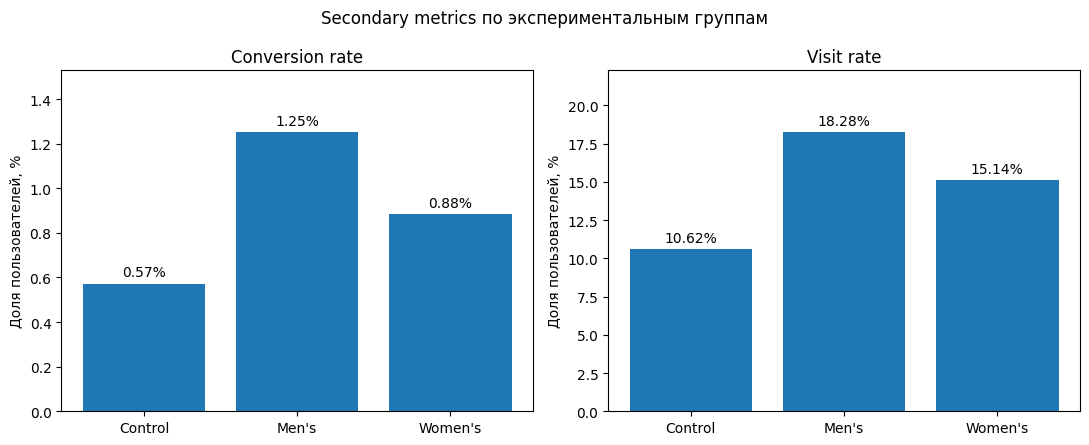

In [16]:
secondary_rates_pct = metric_summary[["conversion_rate", "visit_rate"]] * 100
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, metric, title in zip(
    axes,
    ["conversion_rate", "visit_rate"],
    ["Conversion rate", "Visit rate"],
):
    values = secondary_rates_pct[metric]
    bars = ax.bar(GROUP_LABELS, values.to_numpy())
    ax.bar_label(bars, labels=[f"{value:.2f}%" for value in values], padding=3)
    ax.set_title(title)
    ax.set_ylabel("Доля пользователей, %")
    ax.set_ylim(0, values.max() * 1.22)

fig.suptitle("Secondary metrics по экспериментальным группам")
plt.tight_layout()
plt.show()

## 11. Итог обычного A/B-анализа

Обе e-mail кампании лучше контроля по всем трём наблюдаемым outcome:

- **Spend per User:** положительный uplift и значимый Welch test после Holm;
- **Conversion:** положительная разница долей и значимый z-test после Holm;
- **Visit:** положительная разница долей и значимый z-test после Holm.

Men's E-Mail показывает больший **наблюдаемый** эффект, чем Women's E-Mail, по `spend`, `conversion` и `visit`. Однако из двух отдельных сравнений с контролем нельзя заключать, что Men's статистически значимо лучше Women's: для этого нужен заранее определённый прямой тест `Mens E-Mail` vs `Womens E-Mail` и соответствующая поправка на множественные сравнения.

Практическое ограничение: датасет не содержит unsubscribe, complaints, churn и других guardrail / health метрик. Поэтому рекомендация учитывает краткосрочную эффективность, но не долгосрочный клиентский ущерб.

## 12. Оценка применимости CUPED

**Зачем:** CUPED снижает дисперсию, только если pre-treatment ковариата предсказывает post-treatment outcome. **Что считаем:** корреляции `spend` с доступными числовыми и бинарными pre-treatment признаками внутри Control, где связь не смешана с эффектом письма; дополнительно показываем общую корреляцию `history`–`spend`. **Как читать:** потенциальное снижение дисперсии одномерного CUPED примерно связано с $\rho^2$; корреляции около нуля означают почти нулевой выигрыш.

In [17]:
cuped_features = ["history", "recency", "mens", "womens", "newbie"]
control_data = df.loc[df["segment"] == "No E-Mail"]

control_correlations = (
    control_data[cuped_features + ["spend"]]
    .corr(numeric_only=True)["spend"]
    .loc[cuped_features]
)
cuped_diagnostics = pd.DataFrame({
    "corr_with_spend": control_correlations,
    "rho_squared": control_correlations.pow(2),
    "approx_explained_variation_pct": control_correlations.pow(2) * 100,
})

overall_history_corr = df[["history", "spend"]].corr().loc["history", "spend"]

display(cuped_diagnostics.round(6))
print(f"Overall corr(history, spend) = {overall_history_corr:.6f}")

,corr_with_spend,rho_squared,approx_explained_variation_pct
history,0.014707,0.000216,0.021628
recency,-0.016075,0.000258,0.025842
mens,0.012581,0.000158,0.015828
womens,-0.003344,0.000011,0.001118
newbie,-0.024288,0.000590,0.058991


Overall corr(history, spend) = 0.021729


На Control корреляции равны: `history` 0,0147; `recency` −0,0161; `mens` 0,0126; `womens` −0,0033; `newbie` −0,0243. Общая корреляция `history`–`spend` также мала: около 0,0217.

Максимальная по модулю связь наблюдается у `newbie`: $|\rho|\approx0{,}0243$, поэтому $\rho^2\approx0{,}00059$, или около **0,06%** объясняемой линейной вариации. Методологически pre-treatment данные для CUPED есть, но их предиктивная связь с `spend` слишком слабая. Классический одномерный CUPED здесь практически не снизит дисперсию, поэтому применять его ради формального наличия метода нецелесообразно.